#  Project 2

**Stock Selected:** NVIDIA (NVDA)  
**Machine Learning Model:** Deep Neural Network (DNN)  

This project analyzes NVIDIA (NVDA) stock data from 2016 to 2026 and uses a machine learning model to predict short-term trading signals based on historical price patterns.

It aims to answer this finance question:

Can a deep neural network learn from technical indicators and past returns to predict whether NVDA’s next move is likely to be up, down, or flat?

Then, can that prediction be translated into a simple buy/sell/hold trading strategy?

In [ ]:
# pip install tensorflow

   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.8/351.2 MB 5.1 MB/s eta 0:01:09
   ---------------------------------------- 2.1/351.2 MB 5.2 MB/s eta 0:01:08
   ---------------------------------------- 2.9/351.2 MB 4.9 MB/s eta 0:01:11
   ---------------------------------------- 4.2/351.2 MB 5.1 MB/s eta 0:01:09
    --------------------------------------- 5.0/351.2 MB 5.0 MB/s eta 0:01:10
    --------------------------------------- 5.8/351.2 MB 4.7 MB/s eta 0:01:13
    --------------------------------------- 6.8/351.2 MB 4.7 MB/s eta 0:01:14
    --------------------------------------- 7.9/351.2 MB 4.8 MB/s eta 0:01:12
   - -------------------------------------- 8.9/351.2 MB 4.8 MB/s eta 0:01:12
   - -------------------------------------- 10.2/351.2 MB 4.9 MB/s eta 0:01:10
   - -------------------------------------- 11.5/351.2 MB 5.0 MB/s eta 0:01:09
   - -------------------------------------- 12.6/351.2 MB 5.0 MB/s et


## Section 1: Data Preparation

In [21]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.neural_network import MLPClassifier
plt.style.use('seaborn-v0_8-notebook')

np.random.seed(42)
tf.random.set_seed(42)

### 1.1 Data Download and Cleaning

In [5]:
# Download NVDA data
NVDA = yf.Ticker("NVDA")
data = NVDA.history(start="2016-02-01", end="2026-02-01", interval='1d')

data.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2016-02-01 00:00:00-05:00,0.713688,0.718322,0.707590,0.714664,289884000,0.0,0.0
2016-02-02 00:00:00-05:00,0.707346,0.711005,0.679540,0.684419,341908000,0.0,0.0
2016-02-03 00:00:00-05:00,0.689785,0.693931,0.671979,0.687833,326772000,0.0,0.0
2016-02-04 00:00:00-05:00,0.688809,0.703688,0.681248,0.688077,348140000,0.0,0.0
2016-02-05 00:00:00-05:00,0.683443,0.691004,0.642710,0.644661,600428000,0.0,0.0


In [6]:
# Drop NaN rows and create a clean copy
data.dropna(inplace=True)
data = data.copy()

### 1.2 Raw Price Data Plot

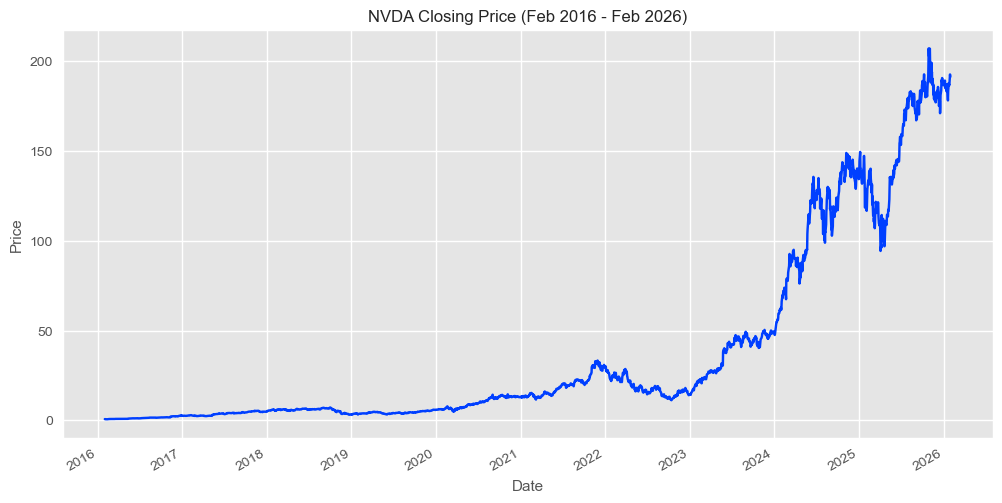

In [16]:
data['Close'].plot(figsize=(12, 6))
plt.title('NVDA Closing Price (Feb 2016 - Feb 2026)')
plt.xlabel('Date')
plt.ylabel('Price')
plt.show()

### 1.3 Feature Construction 

In [ ]:
# Log returns
data['Log_returns'] = np.log(data['Close'] / data['Close'].shift(1))

# Lagged returns
data['Lag1'] = data['Log_returns'].shift(1)
data['Lag2'] = data['Log_returns'].shift(2)
data['Lag3'] = data['Log_returns'].shift(3)

# Moving averages and ratios
data['MA5']  = data['Close'].rolling(window=5).mean()
data['MA20'] = data['Close'].rolling(window=20).mean()
data['MA_ratio'] = data['MA5'] / data['MA20']

# Volatility (rolling std of log returns)
data['Volatility'] = data['Log_returns'].rolling(window=10).std()

# Relative Strength Index (RSI) for 14-day period
delta = data['Close'].diff()
gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)
avg_gain = gain.rolling(window=14).mean()
avg_loss = loss.rolling(window=14).mean()
rs = avg_gain / avg_loss
data['RSI'] = 100 - (100 / (1 + rs))

# Trading target: 1 = Buy, -1 = Sell, 0 = No Change
# First infer the desired market position for the next day: 1 = in market, 0 = out of market.
desired_position = (data['Log_returns'].shift(-1) > 0).astype(float)
desired_position.iloc[-1] = np.nan

# The trading signal is the change in desired position.
data['signal'] = desired_position.sub(desired_position.shift(1))
data['signal'] = data['signal'].where(data['signal'].notna(), desired_position)

data.dropna(inplace=True)
data['signal'] = data['signal'].astype(int)

data.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits,Log_returns,Lag1,Lag2,Lag3,MA5,MA20,MA_ratio,Volatility,Direction,RSI
Date,,,,,,,,,,,,,,,,,
2016-03-28 00:00:00-04:00,0.842606,0.856315,0.841627,0.852643,265388000,0.0,0.0,0.010100,0.001451,0.016989,-0.001771,0.839668,0.804955,1.043124,0.013541,1,75.883752
2016-03-29 00:00:00-04:00,0.848971,0.868310,0.847012,0.866351,261812000,0.0,0.0,0.015950,0.010100,0.001451,0.016989,0.846914,0.809888,1.045718,0.013624,1,88.075406
2016-03-30 00:00:00-04:00,0.869534,0.887404,0.869044,0.875409,376700000,0.0,0.0,0.010401,0.015950,0.010100,0.001451,0.856266,0.813572,1.052476,0.012691,-1,89.279010
2016-03-31 00:00:00-04:00,0.879326,0.881285,0.865372,0.872227,379884000,0.0,0.0,-0.003642,0.010401,0.015950,0.010100,0.862141,0.816865,1.055427,0.011515,1,87.908185
2016-04-01 00:00:00-04:00,0.866841,0.885446,0.860232,0.884956,348292000,0.0,0.0,0.014489,-0.003642,0.010401,0.015950,0.870317,0.821149,1.059877,0.010218,-1,87.861578


### 1.4 Train-Test Split

In [42]:
# train-test split
initial_capital = 10000
train_ratio = 0.8

features = ['Lag1', 'Lag2', 'Lag3', 'MA_ratio', 'Volatility', 'RSI']

split_idx = int(len(data) * train_ratio)

train_data = data.iloc[:split_idx].copy()
test_data  = data.iloc[split_idx:].copy()

X_train = train_data[features].values
y_train = train_data['signal'].values
X_test  = test_data[features].values
y_test  = test_data['signal'].values

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [43]:
# Check class distribution
print("Train set class distribution:")
print(pd.Series(y_train).value_counts(normalize=True))
print("\nTest set class distribution:")
print(pd.Series(y_test).value_counts(normalize=True))

Train set class distribution:
 1    0.547703
-1    0.452297
Name: proportion, dtype: float64

Test set class distribution:
 1    0.53629
-1    0.46371
Name: proportion, dtype: float64


---
## Section 2: Strategy Implementation

### 2.1 Deep Neural Network (DNN) Model

We train a fully-connected DNN with:
- 3 hidden layers (128 → 64 → 32 neurons)
- ReLU activations + Dropout regularisation
- Batch Normalisation for stable training
- Cross-entropy loss for multiclass classification (sell / hold / buy)
- Early stopping to prevent overfitting

In [72]:
model = MLPClassifier(hidden_layer_sizes = 3 * [75], max_iter = 2000, random_state=42)
model.fit(X_train_scaled, y_train)

,hidden_layer_sizes,"[75, 75, ...]"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,2000
,shuffle,True
,random_state,42


In [73]:
# Model accuracy on test set
pred = model.predict(X_test_scaled)
accuracy_score(y_test, pred)

0.5403225806451613

In [65]:
# Correct vs false signal predictions on the full dataset
data['Predicted_Signal'] = model.predict(scaler.transform(data[features].values))
(data['signal'] == data['Predicted_Signal']).value_counts()

c:\Users\cafo4\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but MLPClassifier was fitted without feature names
  warnings.warn(


True     1351
False    1126
Name: count, dtype: int64

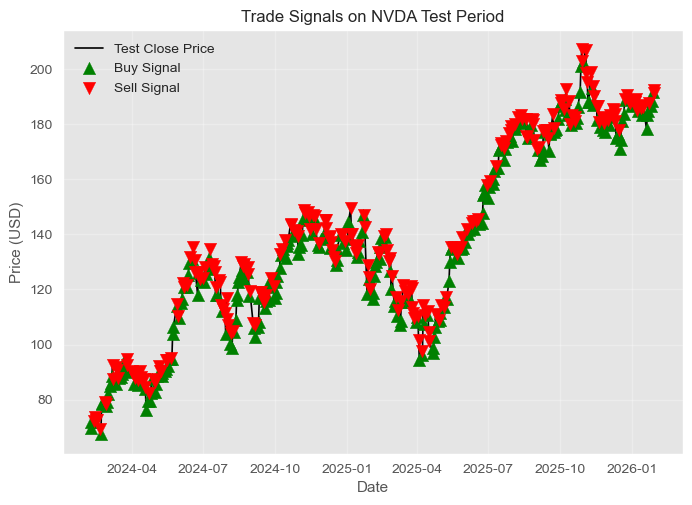

In [ ]:
fig, ax = plt.subplots(figsize=(15, 6))

plot_df = test_data.copy()
plot_df['pred'] = pred
plot_df['correct'] = plot_df['signal'] == plot_df['pred']

buy_pts = plot_df[plot_df['pred'] == 1]
sell_pts = plot_df[plot_df['pred'] == -1]
wrong_pts = plot_df[~plot_df['correct']]

ax.plot(plot_df.index, plot_df['Close'],
        color='slategray', linewidth=1.4, alpha=0.85, label='NVDA Close')

ax.scatter(buy_pts.index, buy_pts['Close'],
           marker='^', color='#2ca02c', s=55, alpha=0.7,
           label='Predicted Buy', zorder=3)

ax.scatter(sell_pts.index, sell_pts['Close'],
           marker='v', color='#d62728', s=55, alpha=0.7,
           label='Predicted Sell', zorder=3)

ax.scatter(wrong_pts.index, wrong_pts['Close'],
           facecolors='none', edgecolors='goldenrod', s=95, linewidths=1.2,
           label='Wrong Prediction', zorder=4)

accuracy = plot_df['correct'].mean()
ax.text(0.01, 0.98, f'Test accuracy: {accuracy:.1%}',
        transform=ax.transAxes, ha='left', va='top',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='lightgray'))

ax.set_title('Predicted Trading Signals on NVDA Test Period', fontsize=14, pad=12)
ax.set_xlabel('Date')
ax.set_ylabel('Close Price (USD)')
ax.legend(ncol=4, frameon=False, loc='upper left')
ax.grid(True, alpha=0.25, linestyle='--')
plt.tight_layout()
plt.show()

### 2.2 Model Evaluation on Test Set

In [31]:
# Predict trading signals on test set
y_pred = model.predict(X_test_scaled)

test_acc = accuracy_score(y_test, y_pred)
print(f"Test Set Accuracy: {test_acc:.4f}")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred, labels=[-1, 0, 1], target_names=['Sell (-1)', 'Hold (0)', 'Buy (1)']))

Test Set Accuracy: 0.5020

Classification Report:
              precision    recall  f1-score   support

   Down (-1)       0.45      0.32      0.38       232
      Up (1)       0.53      0.66      0.59       268

    accuracy                           0.50       500
   macro avg       0.49      0.49      0.48       500
weighted avg       0.49      0.50      0.49       500



### 2.3 Predicted Trading Signals

**Trading rule:**
- If the DNN predicts the next day's return is **Up** (probability ≥ 0.5) → **BUY** (if not already holding)
- If the DNN predicts **Down/Flat** → **SELL** (if currently holding)

The raw DNN direction prediction remains **1 = Up, -1 = Down**.
The trading action column encodes: **1 = Buy, -1 = Sell, 0 = No Change**.

Note: sell signals before any buy signal are ignored, and we do not short-sell.

In [ ]:
test_data = test_data.copy()
test_data['signal'] = y_pred

print(f"Total buy  signals : {(test_data['signal'] == 1).sum()}")
print(f"Total sell signals : {(test_data['signal'] == -1).sum()}")
print(f"Total hold entries : {(test_data['signal'] == 0).sum()}")

### 2.4 Trade Signal Plot

In [ ]:
fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(test_data.index, test_data['Close'], color='steelblue', linewidth=1, label='NVDA Close Price', zorder=1)

# Mark buy signals
buys  = test_data[test_data['signal'] ==  1]
sells = test_data[test_data['signal'] == -1]

ax.scatter(buys.index,  buys['Close'],  marker='^', color='green',  s=80, label='Buy Signal',  zorder=3)
ax.scatter(sells.index, sells['Close'], marker='v', color='red',    s=80, label='Sell Signal', zorder=3)

ax.set_title('DNN Trading Signals on NVDA – Test Period', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## Section 3: Trading Log

We simulate the trading strategy with:
- Initial capital: \$10,000
- No short-selling
- Whole shares only
- All-in buy, all-out sell
- Final position liquidated on the last test day

In [ ]:
cash        = float(initial_capital)
shares_held = 0

log_rows = []

prices      = test_data['Close'].values
daily_ret   = test_data['returns'].values
signal_arr  = test_data['signal'].values
dates       = test_data.index

for i in range(len(test_data)):
    price  = prices[i]
    ret    = daily_ret[i]
    sig    = signal_arr[i]

    # Determine today's trading action
    action = 0

    # Force-sell on last day if still holding
    if i == len(test_data) - 1 and shares_held > 0:
        sig = -1

    if sig == 1:    # Buy
        shares_to_buy = int(cash // price)
        if shares_to_buy > 0:
            shares_held += shares_to_buy
            cash        -= shares_to_buy * price
            action       = 1

    elif sig == -1 and shares_held > 0:  # Sell
        cash        += shares_held * price
        shares_held  = 0
        action       = -1

    stock_value     = shares_held * price
    portfolio_value = cash + stock_value

    log_rows.append({
        'Date'              : dates[i].date(),
        'Price'             : round(price, 4),
        'Daily Return'      : round(ret, 6) if not np.isnan(ret) else 0.0,
        'Trading Action'    : action,
        'Free Cash'         : round(cash, 2),
        'Shares Held'       : shares_held,
        'Cash Invested'     : round(stock_value, 2),
        'Portfolio Value'   : round(portfolio_value, 2),
    })

trade_log = pd.DataFrame(log_rows)
trade_log.set_index('Date', inplace=True)

print("Trade Log (first 20 rows):")
trade_log.head(20)

In [ ]:
# Show only days with actual transactions
transactions = trade_log[trade_log['Trading Action'] != 0]
print(f"\nTransaction Summary ({len(transactions)} transactions):")
transactions

---
## Section 4: Performance Evaluation

In [ ]:
final_portfolio_value = trade_log['Portfolio Value'].iloc[-1]
total_return_pct      = (final_portfolio_value - initial_capital) / initial_capital * 100

print("=" * 45)
print("       DNN STRATEGY – PERFORMANCE SUMMARY")
print("=" * 45)
print(f"  Initial Capital       : ${initial_capital:,.2f}")
print(f"  Final Portfolio Value : ${final_portfolio_value:,.2f}")
print(f"  Total Return          : {total_return_pct:.2f}%")
print("=" * 45)

# Portfolio value over time
plt.figure(figsize=(14, 5))
plt.plot(trade_log.index, trade_log['Portfolio Value'], color='darkorange', linewidth=1.5, label='DNN Strategy')
plt.axhline(initial_capital, color='gray', linestyle='--', linewidth=0.8, label='Initial Capital')
plt.title('DNN Strategy – Portfolio Value Over Test Period', fontsize=13)
plt.xlabel('Date')
plt.ylabel('Portfolio Value (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## Section 5: Benchmark Evaluation – Buy and Hold

The benchmark invests all \$10,000 on the **first trading day** of the test period and holds until the **last trading day**, then liquidates.

In [ ]:
bm_buy_price   = test_data['Close'].iloc[0]
bm_shares      = int(initial_capital // bm_buy_price)
bm_cash_left   = initial_capital - bm_shares * bm_buy_price
bm_sell_price  = test_data['Close'].iloc[-1]
bm_final_value = bm_shares * bm_sell_price + bm_cash_left
bm_return_pct  = (bm_final_value - initial_capital) / initial_capital * 100

print("=" * 45)
print("       BUY-AND-HOLD – PERFORMANCE SUMMARY")
print("=" * 45)
print(f"  Buy Price (Day 1)     : ${bm_buy_price:.4f}")
print(f"  Sell Price (Last Day) : ${bm_sell_price:.4f}")
print(f"  Shares Purchased      : {bm_shares}")
print(f"  Residual Cash         : ${bm_cash_left:.2f}")
print(f"  Initial Capital       : ${initial_capital:,.2f}")
print(f"  Final Portfolio Value : ${bm_final_value:,.2f}")
print(f"  Total Return          : {bm_return_pct:.2f}%")
print("=" * 45)

# Build benchmark daily portfolio value series
bm_portfolio = bm_shares * test_data['Close'] + bm_cash_left

---
## Section 6: Benchmark Comparison

In [ ]:
outperformance = total_return_pct - bm_return_pct

print("=" * 50)
print("            STRATEGY vs BENCHMARK")
print("=" * 50)
print(f"  DNN Strategy Total Return    : {total_return_pct:7.2f}%")
print(f"  Buy-and-Hold Total Return    : {bm_return_pct:7.2f}%")
print(f"  Outperformance (absolute)    : {outperformance:7.2f} pp")
print("=" * 50)

if outperformance >= 5:
    print("  ✅ Strategy outperforms benchmark by ≥ 5 pp – requirement MET.")
else:
    print("  ⚠️  Strategy does NOT outperform benchmark by ≥ 5 pp.")

# --- Comparison chart ---
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(trade_log.index,      trade_log['Portfolio Value'],
        color='darkorange', linewidth=1.8, label=f'DNN Strategy ({total_return_pct:.1f}%)')

ax.plot(test_data.index, bm_portfolio.values,
        color='steelblue', linewidth=1.8, linestyle='--',
        label=f'Buy & Hold ({bm_return_pct:.1f}%)')

ax.axhline(initial_capital, color='gray', linestyle=':', linewidth=0.8, label='Initial Capital $10,000')

ax.set_title('DNN Strategy vs Buy-and-Hold – Test Period', fontsize=13)
ax.set_xlabel('Date')
ax.set_ylabel('Portfolio Value (USD)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()